In [1]:
from keras.datasets import cifar10
(x_train , y_train), (x_test , y_test) = cifar10.load_data()

# Flatten Input 3 Channel
# StandardScaler transform on the dataset and making subset



In [2]:
import torch
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
import numpy as np
from keras.datasets import cifar10
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print(f"the shape of the x_train is {x_train.shape}")
print(f"the shape of the x_test is {x_test.shape}")

x_train_R = x_train.reshape(x_train.shape[0], -1)
x_test_R = x_test.reshape(x_test.shape[0], -1)
print("-----------------------------------------")
print("After reshaping the data to Vector:")
print(f"the shape of the x_train is {x_train_R.shape}")
print(f"the shape of the x_test is {x_test_R.shape}")


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_R)
x_test_scaled = scaler.transform(x_test_R)


n_train_samples = 2000
n_test_samples = 500

x_train_sub = x_train_scaled[:n_train_samples]
y_train_sub = y_train[:n_train_samples].ravel()

x_test_sub = x_test_scaled[:n_test_samples]
y_test_sub = y_test[:n_test_samples].ravel()
print("-----------------------------------------")
print("Data ready")

the shape of the x_train is (50000, 32, 32, 3)
the shape of the x_test is (10000, 32, 32, 3)
-----------------------------------------
After reshaping the data to Vector:
the shape of the x_train is (50000, 3072)
the shape of the x_test is (10000, 3072)
-----------------------------------------
Data ready


In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


#Using Fixed Parametrs for PCA, Isomap and KNN

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


print("--- Fixed Parameters (Subsets) ---")

# PCA + KNN
# Added random_state=42 to PCA for reproducible results
pca_fixed = PCA(n_components=100, random_state=42)
knn_pca_fixed = KNeighborsClassifier(n_neighbors=7, weights='uniform', metric='euclidean')

x_train_sub_pca = pca_fixed.fit_transform(x_train_sub)
x_test_sub_pca = pca_fixed.transform(x_test_sub)

knn_pca_fixed.fit(x_train_sub_pca, y_train_sub)
y_pred_pca = knn_pca_fixed.predict(x_test_sub_pca)
print("Fixed PCA Acc:", accuracy_score(y_test_sub, knn_pca_fixed.predict(x_test_sub_pca)))
print("PCA Classification Report:")
print(classification_report(y_test_sub, y_pred_pca, target_names=class_names))


# ISOMAP + KNN
iso_fixed = Isomap(n_components=50, n_neighbors=15)
knn_iso_fixed = KNeighborsClassifier(n_neighbors=7, weights='uniform')

x_train_sub_iso = iso_fixed.fit_transform(x_train_sub)
x_test_sub_iso = iso_fixed.transform(x_test_sub)

knn_iso_fixed.fit(x_train_sub_iso, y_train_sub)
y_pred_iso = knn_iso_fixed.predict(x_test_sub_iso)
print("Fixed ISOMAP Acc:", accuracy_score(y_test_sub, knn_iso_fixed.predict(x_test_sub_iso)))
print("ISOMAP Classification Report:")
print(classification_report(y_test_sub, y_pred_iso, target_names=class_names))

--- Fixed Parameters (Subsets) ---
Fixed PCA Acc: 0.258
PCA Classification Report:
              precision    recall  f1-score   support

    airplane       0.28      0.56      0.38        57
  automobile       0.67      0.20      0.30        41
        bird       0.21      0.45      0.29        51
         cat       0.35      0.14      0.20        49
        deer       0.09      0.20      0.12        40
         dog       0.18      0.04      0.07        48
        frog       0.24      0.31      0.27        54
       horse       0.30      0.06      0.11        47
        ship       0.42      0.42      0.42        57
       truck       0.45      0.09      0.15        56

    accuracy                           0.26       500
   macro avg       0.32      0.25      0.23       500
weighted avg       0.32      0.26      0.24       500

Fixed ISOMAP Acc: 0.22
ISOMAP Classification Report:
              precision    recall  f1-score   support

    airplane       0.25      0.42      0.31       

#Using Random search for choosing Parametrs

In [6]:

print("--- Random Search (Subsets) ---")

# --- PCA ---
pca_pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('knn', KNeighborsClassifier())
])

pca_param_dist = {
    'pca__n_components': [50, 100, 150, 200], # Removed very large values
    'knn__n_neighbors': [5, 7, 10, 15],
    'knn__weights': ['uniform', 'distance'], # Added distance weighting
    'knn__metric': ['manhattan', 'euclidean'] # Used different distance metrics
}

pca_random_search = RandomizedSearchCV(
    pca_pipeline, param_distributions=pca_param_dist,
    n_iter=15, cv=3, n_jobs=-1, random_state=42
)

pca_random_search.fit(x_train_sub, y_train_sub)
y_pred_pca_random = pca_random_search.predict(x_test_sub)
print("Best PCA Params:", pca_random_search.best_params_)
print("PCA Test Acc:", accuracy_score(y_test_sub, pca_random_search.predict(x_test_sub)))
print("PCA Classification Report:")
print(classification_report(y_test_sub, y_pred_pca_random, target_names=class_names))

# --- ISOMAP ---
iso_pipeline = Pipeline([
    ('isomap', Isomap()),
    ('knn', KNeighborsClassifier())
])

iso_param_dist = {
    'isomap__n_components': [30, 50, 100],
    'isomap__n_neighbors': [10, 15, 20], # Increased Isomap neighbors for better global structure discovery
    'knn__n_neighbors': [5, 7, 10, 15],
    'knn__weights': ['distance','uniform']
}

iso_random_search = RandomizedSearchCV(
    iso_pipeline, param_distributions=iso_param_dist,
    n_iter=10, cv=3, n_jobs=-1, random_state=42
)
iso_random_search.fit(x_train_sub, y_train_sub)
y_pred_iso_R = iso_random_search.predict(x_test_sub)
print("\nBest ISOMAP Params:", iso_random_search.best_params_)
print("ISOMAP Test Acc:", accuracy_score(y_test_sub, iso_random_search.predict(x_test_sub)))
print("ISOMAP Classification Report:")
print(classification_report(y_test_sub, y_pred_iso_R, target_names=class_names))

--- Random Search (Subsets) ---
Best PCA Params: {'pca__n_components': 50, 'knn__weights': 'uniform', 'knn__n_neighbors': 15, 'knn__metric': 'euclidean'}
PCA Test Acc: 0.27
PCA Classification Report:
              precision    recall  f1-score   support

    airplane       0.26      0.42      0.32        57
  automobile       0.62      0.12      0.20        41
        bird       0.22      0.37      0.27        51
         cat       0.30      0.06      0.10        49
        deer       0.13      0.28      0.18        40
         dog       0.43      0.06      0.11        48
        frog       0.24      0.48      0.32        54
       horse       0.30      0.06      0.11        47
        ship       0.41      0.53      0.46        57
       truck       0.55      0.20      0.29        56

    accuracy                           0.27       500
   macro avg       0.35      0.26      0.24       500
weighted avg       0.35      0.27      0.25       500


Best ISOMAP Params: {'knn__weights': 'di

#Using all training Data for PCA + KNN

In [7]:

print("--- FULL Training Data: PCA + KNN ---")

# Use PCA to keep 90% of the variance (or use a fixed number like 50)
pca_full = PCA(n_components=50, random_state=42)

print("Fitting PCA on 50,000 samples...")
# Fit on all standardized training data
x_train_full_pca = pca_full.fit_transform(x_train_scaled)
x_test_full_pca = pca_full.transform(x_test_scaled)

print(f"Reduced features from 3072 to {x_train_full_pca.shape[1]}")

# Train KNN on the full dataset
knn_full = KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='euclidean', n_jobs=-1)

print("Training KNN on 50,000 samples...")
knn_full.fit(x_train_full_pca, y_train.ravel())

print("Predicting on Test Data...")
y_pred_full = knn_full.predict(x_test_full_pca)

print("Full Dataset Accuracy:", accuracy_score(y_test.ravel(), y_pred_full))
print("PCA Classification Report:")
print(classification_report(y_test.ravel(), y_pred_full, target_names=class_names))

--- FULL Training Data: PCA + KNN ---
Fitting PCA on 50,000 samples...
Reduced features from 3072 to 50
Training KNN on 50,000 samples...
Predicting on Test Data...
Full Dataset Accuracy: 0.4104
PCA Classification Report:
              precision    recall  f1-score   support

    airplane       0.48      0.58      0.52      1000
  automobile       0.66      0.35      0.46      1000
        bird       0.27      0.41      0.33      1000
         cat       0.36      0.20      0.26      1000
        deer       0.29      0.51      0.37      1000
         dog       0.53      0.26      0.35      1000
        frog       0.35      0.53      0.42      1000
       horse       0.64      0.30      0.41      1000
        ship       0.45      0.66      0.54      1000
       truck       0.67      0.30      0.41      1000

    accuracy                           0.41     10000
   macro avg       0.47      0.41      0.41     10000
weighted avg       0.47      0.41      0.41     10000



In [4]:
print(f"shape of the x_train:{x_train.shape}")
print(f"shape of the x_test:{x_test.shape}")

shape of the x_train:(50000, 32, 32, 3)
shape of the x_test:(10000, 32, 32, 3)


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from keras.datasets import cifar10
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


x_train_t1 = np.transpose(x_train, (0, 3, 1, 2)).astype('float32') / 255.0
x_test_t1 = np.transpose(x_test, (0, 3, 1, 2)).astype('float32') / 255.0


y_train_f1 = y_train.flatten()
y_test_f1 = y_test.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

train_dataset = TensorDataset(torch.tensor(x_train_t1), torch.tensor(y_train_f1))
test_dataset = TensorDataset(torch.tensor(x_test_t1), torch.tensor(y_test_f1))


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#Autoencoder

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [6]:
def xavier_initialize(model):
    modules = [
        m for n, m in model.named_modules() if
        'conv' in n or 'linear' in n or 'fc_' in n or 'project' in n or 'q_' in n
    ]
    parameters = [
        p for m in modules for p in m.parameters() if p.dim() >= 2
    ]
    for p in parameters:
        init.xavier_normal_(p)

In [13]:
# ==========================================
# 2. Architectures (Dense)
# ==========================================
class DenseAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(DenseAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 32 * 32 * 3),
            nn.Sigmoid()
        )

    def encode(self, x):
        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        out = self.decoder(z)
        return out

In [16]:
def extract_features(model, dataloader):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            z = model.encode(data) # حالا بدون ارور کار می‌کند
            features.append(z.cpu().numpy())
            labels.append(target.cpu().numpy())
    return np.vstack(features), np.concatenate(labels)


# ==========================================
# 4. Training Loop
# ==========================================
latent_dims = [64, 100]

def train_and_evaluate(model_class, model_name, epochs=10, lr=5e-4, weight_decay=1e-5, is_dense=False):
    trained_models = {}
    histories = {}

    for latent_dim in latent_dims:
        print(f"\n{'='*60}")
        print(f"Training {model_name} with Latent Dimension = {latent_dim}")
        print(f"{'='*60}")

        history_key = f"{model_name} ({latent_dim}D)"
        histories[history_key] = []

        model = model_class(latent_dim).to(device)
        xavier_initialize(model)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            data_stream = tqdm(enumerate(train_loader, 1), total=len(train_loader))
            running_loss = 0.0

            for batch_index, (x, _) in data_stream:
                x = x.to(device)
                optimizer.zero_grad()

                x_reconstructed = model(x)

                if is_dense:
                    x_reconstructed = x_reconstructed.view(-1, 3, 32, 32)


                loss = F.mse_loss(x_reconstructed, x, reduction='sum')/x.size(0)

                loss.backward()
                optimizer.step()

                running_loss += loss.item()

                data_stream.set_description(
                    f'Epoch: {epoch} | Loss: {loss.item():.4f}'
                )


            epoch_loss = running_loss / len(train_loader)
            histories[history_key].append(epoch_loss)

        trained_models[latent_dim] = model

        print(f"\n[Extracting Features & Training KNN...] Model: {model_name} | Latent Dim: {latent_dim}D")
        z_train, aligned_y_train = extract_features(model, train_loader)
        z_test, aligned_y_test = extract_features(model, test_loader)

        knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
        knn.fit(z_train, aligned_y_train)

        y_pred = knn.predict(z_test)
        print(f"\nClassification Report for {model_name} (Latent Dim: {latent_dim}):")
        print(classification_report(aligned_y_test, y_pred, target_names=class_names))

    return trained_models, histories

In [17]:
# ==========================================
# 5. Execute and Plot
# ==========================================
dense_models, dense_history = train_and_evaluate(DenseAutoencoder, "DenseAutoencoder", epochs=10, is_dense=True)


Training DenseAutoencoder with Latent Dimension = 64


Epoch: 1 | Loss: 70.6154: 100%|██████████| 391/391 [00:08<00:00, 43.80it/s]
Epoch: 2 | Loss: 67.0026: 100%|██████████| 391/391 [00:06<00:00, 63.23it/s]
Epoch: 3 | Loss: 56.8596: 100%|██████████| 391/391 [00:04<00:00, 84.30it/s]
Epoch: 4 | Loss: 48.6553: 100%|██████████| 391/391 [00:05<00:00, 77.11it/s]
Epoch: 5 | Loss: 48.2749: 100%|██████████| 391/391 [00:04<00:00, 95.85it/s] 
Epoch: 6 | Loss: 49.2175: 100%|██████████| 391/391 [00:03<00:00, 107.69it/s]
Epoch: 7 | Loss: 42.2803: 100%|██████████| 391/391 [00:05<00:00, 73.68it/s]
Epoch: 8 | Loss: 40.8279: 100%|██████████| 391/391 [00:02<00:00, 149.76it/s]
Epoch: 9 | Loss: 40.8567: 100%|██████████| 391/391 [00:02<00:00, 163.70it/s]
Epoch: 10 | Loss: 46.0635: 100%|██████████| 391/391 [00:02<00:00, 161.54it/s]



[Extracting Features & Training KNN...] Model: DenseAutoencoder | Latent Dim: 64D

Classification Report for DenseAutoencoder (Latent Dim: 64):
              precision    recall  f1-score   support

    airplane       0.42      0.63      0.51      1000
  automobile       0.57      0.45      0.50      1000
        bird       0.30      0.43      0.35      1000
         cat       0.34      0.27      0.30      1000
        deer       0.33      0.44      0.37      1000
         dog       0.46      0.29      0.36      1000
        frog       0.41      0.49      0.45      1000
       horse       0.59      0.36      0.45      1000
        ship       0.53      0.62      0.57      1000
       truck       0.64      0.34      0.45      1000

    accuracy                           0.43     10000
   macro avg       0.46      0.43      0.43     10000
weighted avg       0.46      0.43      0.43     10000


Training DenseAutoencoder with Latent Dimension = 100


Epoch: 1 | Loss: 71.5308: 100%|██████████| 391/391 [00:02<00:00, 159.12it/s]
Epoch: 2 | Loss: 57.8846: 100%|██████████| 391/391 [00:02<00:00, 160.70it/s]
Epoch: 3 | Loss: 51.2080: 100%|██████████| 391/391 [00:02<00:00, 161.05it/s]
Epoch: 4 | Loss: 50.2873: 100%|██████████| 391/391 [00:02<00:00, 155.39it/s]
Epoch: 5 | Loss: 48.6606: 100%|██████████| 391/391 [00:02<00:00, 140.59it/s]
Epoch: 6 | Loss: 47.7692: 100%|██████████| 391/391 [00:02<00:00, 158.20it/s]
Epoch: 7 | Loss: 46.6314: 100%|██████████| 391/391 [00:02<00:00, 158.25it/s]
Epoch: 8 | Loss: 45.8989: 100%|██████████| 391/391 [00:02<00:00, 158.05it/s]
Epoch: 9 | Loss: 39.2947: 100%|██████████| 391/391 [00:02<00:00, 151.38it/s]
Epoch: 10 | Loss: 40.9546: 100%|██████████| 391/391 [00:02<00:00, 140.13it/s]



[Extracting Features & Training KNN...] Model: DenseAutoencoder | Latent Dim: 100D

Classification Report for DenseAutoencoder (Latent Dim: 100):
              precision    recall  f1-score   support

    airplane       0.44      0.64      0.52      1000
  automobile       0.57      0.48      0.52      1000
        bird       0.31      0.45      0.37      1000
         cat       0.34      0.27      0.30      1000
        deer       0.34      0.42      0.37      1000
         dog       0.48      0.31      0.38      1000
        frog       0.43      0.52      0.47      1000
       horse       0.61      0.39      0.48      1000
        ship       0.55      0.62      0.58      1000
       truck       0.61      0.33      0.43      1000

    accuracy                           0.44     10000
   macro avg       0.47      0.44      0.44     10000
weighted avg       0.47      0.44      0.44     10000



In [21]:
class ConvAutoencoder(nn.Module):

    def __init__(self, latent_dim):

        super(ConvAutoencoder, self).__init__()



        self.encoder_cnn = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),



            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),

            nn.BatchNorm2d(64),

            nn.ReLU(),



            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),

            nn.BatchNorm2d(128),

            nn.ReLU(),

        )

        self.encoder_fc = nn.Linear(128 * 4 * 4, latent_dim)



        self.decoder_fc = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder_cnn = nn.Sequential(

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),

            nn.BatchNorm2d(64),

            nn.ReLU(),



            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),



            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),

            nn.Sigmoid()

        )



    def encode(self, x):

        x = self.encoder_cnn(x)

        x = x.view(x.size(0), -1)

        z = self.encoder_fc(x)

        return z



    def forward(self, x):

        x = self.encoder_cnn(x)

        x = x.view(x.size(0), -1)

        z = self.encoder_fc(x)



        z = self.decoder_fc(z)

        z = z.view(z.size(0), 128, 4, 4)

        out = self.decoder_cnn(z)

        return out

In [22]:
cnn_models, cnn_history = train_and_evaluate(ConvAutoencoder, "CNNAutoencoder", epochs=10, is_dense=False)


Training CNNAutoencoder with Latent Dimension = 64


Epoch: 1 | Loss: 33.9659: 100%|██████████| 391/391 [00:06<00:00, 60.91it/s]
Epoch: 2 | Loss: 28.2404: 100%|██████████| 391/391 [00:05<00:00, 66.85it/s]
Epoch: 3 | Loss: 26.9078: 100%|██████████| 391/391 [00:06<00:00, 63.92it/s] 
Epoch: 4 | Loss: 24.1028: 100%|██████████| 391/391 [00:02<00:00, 130.50it/s]
Epoch: 5 | Loss: 27.4206: 100%|██████████| 391/391 [00:03<00:00, 129.62it/s]
Epoch: 6 | Loss: 25.8437: 100%|██████████| 391/391 [00:03<00:00, 120.02it/s]
Epoch: 7 | Loss: 29.2085: 100%|██████████| 391/391 [00:03<00:00, 120.99it/s]
Epoch: 8 | Loss: 23.6200: 100%|██████████| 391/391 [00:03<00:00, 122.07it/s]
Epoch: 9 | Loss: 25.7635: 100%|██████████| 391/391 [00:03<00:00, 129.48it/s]
Epoch: 10 | Loss: 21.8729: 100%|██████████| 391/391 [00:03<00:00, 122.50it/s]



[Extracting Features & Training KNN...] Model: CNNAutoencoder | Latent Dim: 64D

Classification Report for CNNAutoencoder (Latent Dim: 64):
              precision    recall  f1-score   support

    airplane       0.42      0.60      0.50      1000
  automobile       0.70      0.33      0.45      1000
        bird       0.25      0.45      0.32      1000
         cat       0.33      0.18      0.24      1000
        deer       0.28      0.53      0.36      1000
         dog       0.50      0.24      0.32      1000
        frog       0.37      0.44      0.40      1000
       horse       0.66      0.30      0.42      1000
        ship       0.47      0.67      0.55      1000
       truck       0.73      0.26      0.38      1000

    accuracy                           0.40     10000
   macro avg       0.47      0.40      0.39     10000
weighted avg       0.47      0.40      0.39     10000


Training CNNAutoencoder with Latent Dimension = 100


Epoch: 1 | Loss: 34.4302: 100%|██████████| 391/391 [00:03<00:00, 121.70it/s]
Epoch: 2 | Loss: 25.6859: 100%|██████████| 391/391 [00:03<00:00, 128.83it/s]
Epoch: 3 | Loss: 19.7213: 100%|██████████| 391/391 [00:03<00:00, 118.38it/s]
Epoch: 4 | Loss: 18.5435: 100%|██████████| 391/391 [00:02<00:00, 130.96it/s]
Epoch: 5 | Loss: 19.6013: 100%|██████████| 391/391 [00:02<00:00, 131.26it/s]
Epoch: 6 | Loss: 17.6557: 100%|██████████| 391/391 [00:03<00:00, 122.72it/s]
Epoch: 7 | Loss: 19.1171: 100%|██████████| 391/391 [00:03<00:00, 118.28it/s]
Epoch: 8 | Loss: 21.4673: 100%|██████████| 391/391 [00:03<00:00, 127.02it/s]
Epoch: 9 | Loss: 18.2278: 100%|██████████| 391/391 [00:03<00:00, 128.68it/s]
Epoch: 10 | Loss: 18.1482: 100%|██████████| 391/391 [00:03<00:00, 124.75it/s]



[Extracting Features & Training KNN...] Model: CNNAutoencoder | Latent Dim: 100D

Classification Report for CNNAutoencoder (Latent Dim: 100):
              precision    recall  f1-score   support

    airplane       0.44      0.58      0.50      1000
  automobile       0.73      0.26      0.38      1000
        bird       0.25      0.47      0.32      1000
         cat       0.32      0.18      0.23      1000
        deer       0.26      0.57      0.35      1000
         dog       0.48      0.20      0.29      1000
        frog       0.35      0.39      0.37      1000
       horse       0.66      0.27      0.39      1000
        ship       0.47      0.66      0.55      1000
       truck       0.76      0.21      0.32      1000

    accuracy                           0.38     10000
   macro avg       0.47      0.38      0.37     10000
weighted avg       0.47      0.38      0.37     10000



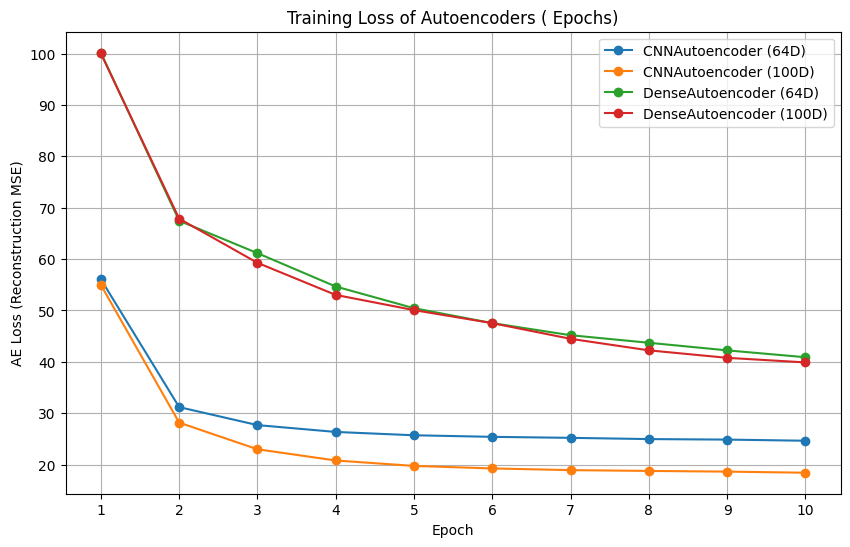

In [23]:
import matplotlib.pyplot as plt
histories = {**cnn_history, **dense_history}

plt.figure(figsize=(10, 6))
for key, loss_values in histories.items():
    plt.plot(range(1, 11), loss_values, marker='o', label=key)

plt.title('Training Loss of Autoencoders ( Epochs)')
plt.xlabel('Epoch')
plt.ylabel('AE Loss (Reconstruction MSE)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

#Variational Auto Encoder

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [7]:
class DenseVAE(nn.Module):
    def __init__(self, z_size):
        super(DenseVAE, self).__init__()
        self.z_size = z_size

        self.encoder = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, z_size)
        self.fc_logvar = nn.Linear(256, z_size)

        self.decoder = nn.Sequential(
            nn.Linear(z_size, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 32 * 32 * 3),
            nn.Sigmoid()
        )

    def encode(self, x):

        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        if len(x.shape) > 2:
            x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        out = self.decoder(z)
        return out, mu, logvar

In [8]:
class VAE(nn.Module):
    def __init__(self, z_size, image_size=32, channel_num=3, kernel_num=128):
        super().__init__()
        self.image_size = image_size
        self.channel_num = channel_num
        self.kernel_num = kernel_num
        self.z_size = z_size


        self.encoder = nn.Sequential(
            self._conv(channel_num, kernel_num // 4),
            self._conv(kernel_num // 4, kernel_num // 2),
            self._conv(kernel_num // 2, kernel_num),
        )

        self.feature_size = image_size // 8
        self.feature_volume = kernel_num * (self.feature_size ** 2)

        self.q_mean = nn.Linear(self.feature_volume, z_size)
        self.q_logvar = nn.Linear(self.feature_volume, z_size)
        self.project = nn.Linear(z_size, self.feature_volume)


        self.decoder = nn.Sequential(
            self._deconv(kernel_num, kernel_num // 2),
            self._deconv(kernel_num // 2, kernel_num // 4),
            self._deconv(kernel_num // 4, channel_num),
            nn.Sigmoid()
        )

    def forward(self, x):
        mean, logvar, z = self.encode(x)
        z_projected = self.project(z).view(
            -1, self.kernel_num,
            self.feature_size,
            self.feature_size,
        )
        x_reconstructed = self.decoder(z_projected)
        return (mean, logvar), x_reconstructed

    def encode(self, x):
        encoded = self.encoder(x)
        mean, logvar = self.q(encoded)
        z = self.z(mean, logvar)
        return mean, logvar, z

    def q(self, encoded):
        unrolled = encoded.view(-1, self.feature_volume)
        return self.q_mean(unrolled), self.q_logvar(unrolled)

    def z(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def _conv(self, channel_size, kernel_num):
        return nn.Sequential(
            nn.Conv2d(channel_size, kernel_num, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(kernel_num),
            nn.LeakyReLU(0.2),
        )

    def _deconv(self, channel_num, kernel_num):
        return nn.Sequential(
            nn.ConvTranspose2d(channel_num, kernel_num, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(kernel_num),
            nn.LeakyReLU(0.2),
        )

In [9]:
def xavier_initialize(model):
    modules = [
        m for n, m in model.named_modules() if
        'conv' in n or 'linear' in n or 'fc_' in n or 'project' in n or 'q_' in n
    ]
    parameters = [
        p for m in modules for p in m.parameters() if p.dim() >= 2
    ]
    for p in parameters:
        init.xavier_normal_(p)

In [10]:
latent_dims = [64 , 100]
def extract_features(model, dataloader, is_dense=False):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            encoded_out = model.encode(data)


            if is_dense:
                mu, _ = encoded_out
            else:
                mu, _, _ = encoded_out

            features.append(mu.cpu().numpy())
            labels.append(target.cpu().numpy())

    return np.vstack(features), np.concatenate(labels)


def train_and_evaluate(model_class, model_name, epochs=10, lr=5e-4, weight_decay=1e-5, beta=0.2, is_dense=False):
    trained_models = {}
    histories = {}

    for latent_dim in latent_dims:
        print(f"\n{'='*60}")
        print(f"Training {model_name} with Latent Dimension = {latent_dim}")
        print(f"{'='*60}")


        history_key = f"{model_name} ({latent_dim}D)"
        histories[history_key] = []

        if is_dense:
            model = model_class(z_size=latent_dim).to(device)
        else:
            model = model_class(z_size=latent_dim).to(device)

        xavier_initialize(model)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            data_stream = tqdm(enumerate(train_loader, 1), total=len(train_loader))

            running_total = 0.0

            for batch_index, (x, _) in data_stream:
                x = x.to(device)
                optimizer.zero_grad()

                outputs = model(x)

                if is_dense:
                    x_reconstructed, mean, logvar = outputs
                    x_reconstructed = x_reconstructed.view(-1, 3, 32, 32)
                else:
                    (mean, logvar), x_reconstructed = outputs

                reconstruction_loss = F.mse_loss(x_reconstructed, x, reduction='sum') / x.size(0)
                kl_divergence_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp(), dim=1).mean()

                total_loss = reconstruction_loss + (beta * kl_divergence_loss)

                total_loss.backward()
                optimizer.step()

                running_total += total_loss.item()

                data_stream.set_description(
                    f'Epoch: {epoch} | '
                    f'loss => total: {total_loss.item():.2f} / '
                    f're: {reconstruction_loss.item():.2f} / '
                    f'kl: {kl_divergence_loss.item():.2f}'
                )


            epoch_loss = running_total / len(train_loader)
            histories[history_key].append(epoch_loss)

        trained_models[latent_dim] = model

        print(f"\n[Extracting Features & Training KNN...] Model: {model_name} | Latent Dim: {latent_dim}D")
        z_train, aligned_y_train = extract_features(model, train_loader, is_dense=is_dense)
        z_test, aligned_y_test = extract_features(model, test_loader, is_dense=is_dense)

        knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
        knn.fit(z_train, aligned_y_train)

        y_pred = knn.predict(z_test)
        print(f"\nClassification Report for {model_name} (Latent Dim: {latent_dim}):")
        print(classification_report(aligned_y_test, y_pred, target_names=class_names))

    return trained_models, histories

In [11]:
dense_models, dense_history = train_and_evaluate(DenseVAE, "DenseVAE", epochs=10, lr=5e-4, beta=0.15, is_dense=True)


Training DenseVAE with Latent Dimension = 64


Epoch: 1 | loss => total: 94.17 / re: 86.99 / kl: 47.85: 100%|██████████| 391/391 [00:03<00:00, 106.38it/s]
Epoch: 2 | loss => total: 79.74 / re: 72.55 / kl: 47.97: 100%|██████████| 391/391 [00:02<00:00, 135.51it/s]
Epoch: 3 | loss => total: 77.48 / re: 70.44 / kl: 46.90: 100%|██████████| 391/391 [00:02<00:00, 138.51it/s]
Epoch: 4 | loss => total: 68.98 / re: 62.31 / kl: 44.47: 100%|██████████| 391/391 [00:03<00:00, 118.07it/s]
Epoch: 5 | loss => total: 62.97 / re: 56.53 / kl: 42.99: 100%|██████████| 391/391 [00:02<00:00, 139.68it/s]
Epoch: 6 | loss => total: 64.35 / re: 57.29 / kl: 47.04: 100%|██████████| 391/391 [00:02<00:00, 136.69it/s]
Epoch: 7 | loss => total: 61.59 / re: 54.76 / kl: 45.55: 100%|██████████| 391/391 [00:02<00:00, 138.19it/s]
Epoch: 8 | loss => total: 55.49 / re: 49.05 / kl: 42.92: 100%|██████████| 391/391 [00:03<00:00, 120.13it/s]
Epoch: 9 | loss => total: 56.20 / re: 49.92 / kl: 41.88: 100%|██████████| 391/391 [00:02<00:00, 137.58it/s]
Epoch: 10 | loss => total: 5


[Extracting Features & Training KNN...] Model: DenseVAE | Latent Dim: 64D

Classification Report for DenseVAE (Latent Dim: 64):
              precision    recall  f1-score   support

    airplane       0.43      0.60      0.50      1000
  automobile       0.54      0.48      0.51      1000
        bird       0.29      0.43      0.34      1000
         cat       0.30      0.22      0.26      1000
        deer       0.32      0.40      0.36      1000
         dog       0.44      0.29      0.35      1000
        frog       0.40      0.50      0.45      1000
       horse       0.55      0.40      0.46      1000
        ship       0.55      0.56      0.56      1000
       truck       0.60      0.34      0.43      1000

    accuracy                           0.42     10000
   macro avg       0.44      0.42      0.42     10000
weighted avg       0.44      0.42      0.42     10000


Training DenseVAE with Latent Dimension = 100


Epoch: 1 | loss => total: 90.21 / re: 83.55 / kl: 44.44: 100%|██████████| 391/391 [00:03<00:00, 124.59it/s]
Epoch: 2 | loss => total: 81.44 / re: 74.18 / kl: 48.34: 100%|██████████| 391/391 [00:02<00:00, 138.87it/s]
Epoch: 3 | loss => total: 83.26 / re: 76.89 / kl: 42.49: 100%|██████████| 391/391 [00:02<00:00, 136.99it/s]
Epoch: 4 | loss => total: 69.61 / re: 63.52 / kl: 40.58: 100%|██████████| 391/391 [00:02<00:00, 140.26it/s]
Epoch: 5 | loss => total: 73.15 / re: 66.86 / kl: 41.95: 100%|██████████| 391/391 [00:03<00:00, 121.24it/s]
Epoch: 6 | loss => total: 63.56 / re: 56.82 / kl: 44.94: 100%|██████████| 391/391 [00:02<00:00, 138.00it/s]
Epoch: 7 | loss => total: 66.57 / re: 60.24 / kl: 42.22: 100%|██████████| 391/391 [00:02<00:00, 139.48it/s]
Epoch: 8 | loss => total: 57.66 / re: 50.96 / kl: 44.68: 100%|██████████| 391/391 [00:02<00:00, 136.61it/s]
Epoch: 9 | loss => total: 57.12 / re: 50.72 / kl: 42.65: 100%|██████████| 391/391 [00:03<00:00, 121.07it/s]
Epoch: 10 | loss => total: 6


[Extracting Features & Training KNN...] Model: DenseVAE | Latent Dim: 100D

Classification Report for DenseVAE (Latent Dim: 100):
              precision    recall  f1-score   support

    airplane       0.43      0.60      0.50      1000
  automobile       0.51      0.45      0.48      1000
        bird       0.29      0.44      0.35      1000
         cat       0.29      0.23      0.26      1000
        deer       0.33      0.38      0.35      1000
         dog       0.42      0.25      0.32      1000
        frog       0.39      0.49      0.43      1000
       horse       0.51      0.39      0.44      1000
        ship       0.54      0.54      0.54      1000
       truck       0.58      0.34      0.43      1000

    accuracy                           0.41     10000
   macro avg       0.43      0.41      0.41     10000
weighted avg       0.43      0.41      0.41     10000



In [12]:
cnn_models, cnn_history = train_and_evaluate(VAE, "Custom_CNN_VAE", epochs=10, lr=5e-4, beta=0.15, is_dense=False)


Training Custom_CNN_VAE with Latent Dimension = 64


Epoch: 1 | loss => total: 109.02 / re: 100.97 / kl: 53.68: 100%|██████████| 391/391 [00:04<00:00, 93.44it/s] 
Epoch: 2 | loss => total: 84.48 / re: 75.56 / kl: 59.51: 100%|██████████| 391/391 [00:03<00:00, 111.12it/s]
Epoch: 3 | loss => total: 66.82 / re: 57.28 / kl: 63.60: 100%|██████████| 391/391 [00:03<00:00, 103.51it/s]
Epoch: 4 | loss => total: 67.42 / re: 57.46 / kl: 66.42: 100%|██████████| 391/391 [00:03<00:00, 111.11it/s]
Epoch: 5 | loss => total: 67.75 / re: 57.69 / kl: 67.09: 100%|██████████| 391/391 [00:03<00:00, 110.47it/s]
Epoch: 6 | loss => total: 60.34 / re: 49.94 / kl: 69.32: 100%|██████████| 391/391 [00:03<00:00, 100.36it/s]
Epoch: 7 | loss => total: 57.88 / re: 47.13 / kl: 71.68: 100%|██████████| 391/391 [00:03<00:00, 111.21it/s]
Epoch: 8 | loss => total: 52.09 / re: 41.34 / kl: 71.70: 100%|██████████| 391/391 [00:03<00:00, 109.82it/s]
Epoch: 9 | loss => total: 53.29 / re: 42.31 / kl: 73.20: 100%|██████████| 391/391 [00:03<00:00, 105.24it/s]
Epoch: 10 | loss => total:


[Extracting Features & Training KNN...] Model: Custom_CNN_VAE | Latent Dim: 64D

Classification Report for Custom_CNN_VAE (Latent Dim: 64):
              precision    recall  f1-score   support

    airplane       0.39      0.62      0.48      1000
  automobile       0.75      0.27      0.40      1000
        bird       0.24      0.51      0.33      1000
         cat       0.38      0.17      0.24      1000
        deer       0.28      0.55      0.37      1000
         dog       0.51      0.18      0.26      1000
        frog       0.34      0.43      0.38      1000
       horse       0.77      0.28      0.42      1000
        ship       0.49      0.65      0.56      1000
       truck       0.82      0.12      0.22      1000

    accuracy                           0.38     10000
   macro avg       0.50      0.38      0.36     10000
weighted avg       0.50      0.38      0.36     10000


Training Custom_CNN_VAE with Latent Dimension = 100


Epoch: 1 | loss => total: 110.82 / re: 102.14 / kl: 57.90: 100%|██████████| 391/391 [00:03<00:00, 99.86it/s] 
Epoch: 2 | loss => total: 84.64 / re: 75.63 / kl: 60.10: 100%|██████████| 391/391 [00:03<00:00, 102.45it/s]
Epoch: 3 | loss => total: 75.91 / re: 66.76 / kl: 60.99: 100%|██████████| 391/391 [00:03<00:00, 108.12it/s]
Epoch: 4 | loss => total: 64.35 / re: 55.04 / kl: 62.08: 100%|██████████| 391/391 [00:03<00:00, 104.84it/s]
Epoch: 5 | loss => total: 64.48 / re: 54.29 / kl: 67.92: 100%|██████████| 391/391 [00:03<00:00, 100.18it/s]
Epoch: 6 | loss => total: 58.70 / re: 47.98 / kl: 71.46: 100%|██████████| 391/391 [00:03<00:00, 107.63it/s]
Epoch: 7 | loss => total: 56.75 / re: 45.40 / kl: 75.71: 100%|██████████| 391/391 [00:03<00:00, 106.07it/s]
Epoch: 8 | loss => total: 55.59 / re: 44.37 / kl: 74.75: 100%|██████████| 391/391 [00:04<00:00, 97.38it/s] 
Epoch: 9 | loss => total: 50.21 / re: 38.66 / kl: 77.01: 100%|██████████| 391/391 [00:03<00:00, 106.07it/s]
Epoch: 10 | loss => total:


[Extracting Features & Training KNN...] Model: Custom_CNN_VAE | Latent Dim: 100D

Classification Report for Custom_CNN_VAE (Latent Dim: 100):
              precision    recall  f1-score   support

    airplane       0.38      0.61      0.47      1000
  automobile       0.78      0.23      0.36      1000
        bird       0.23      0.52      0.32      1000
         cat       0.38      0.16      0.23      1000
        deer       0.27      0.55      0.36      1000
         dog       0.48      0.16      0.24      1000
        frog       0.36      0.41      0.38      1000
       horse       0.80      0.24      0.37      1000
        ship       0.45      0.63      0.52      1000
       truck       0.81      0.09      0.16      1000

    accuracy                           0.36     10000
   macro avg       0.49      0.36      0.34     10000
weighted avg       0.49      0.36      0.34     10000



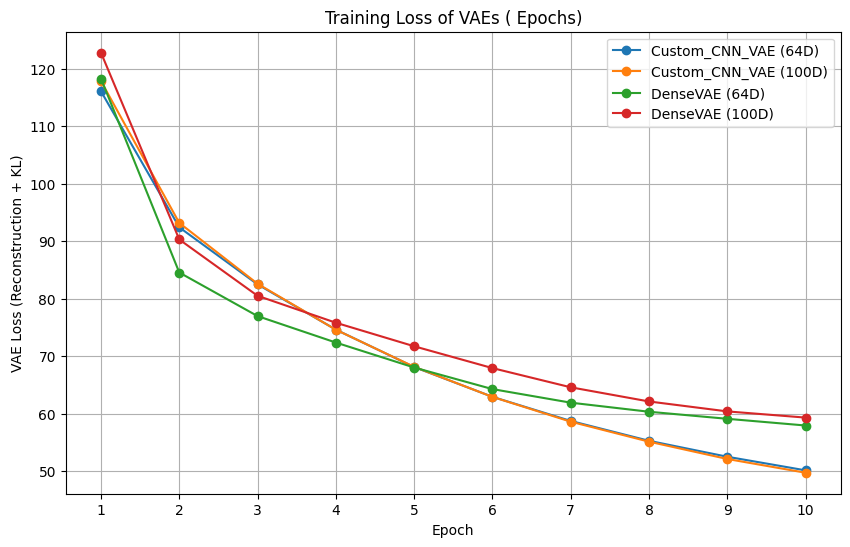

In [13]:
histories = {**cnn_history, **dense_history}
plt.figure(figsize=(10, 6))
for key, loss_values in histories.items():
    plt.plot(range(1, 11), loss_values, marker='o', label=key)

plt.title('Training Loss of VAEs ( Epochs)')
plt.xlabel('Epoch')
plt.ylabel('VAE Loss (Reconstruction + KL)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()

#Exploring in latent Space

In [14]:
target_latent_dim = 100
model = cnn_models[target_latent_dim]
model.eval()

VAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (q_mean): Linear(in_features=2048, out_features=100, bias=True)
  (q_logvar): Linear(in_features=2048, out_features=100, bias=True)
  (project): Linear(in_features=100, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): Sequential(
      (0):

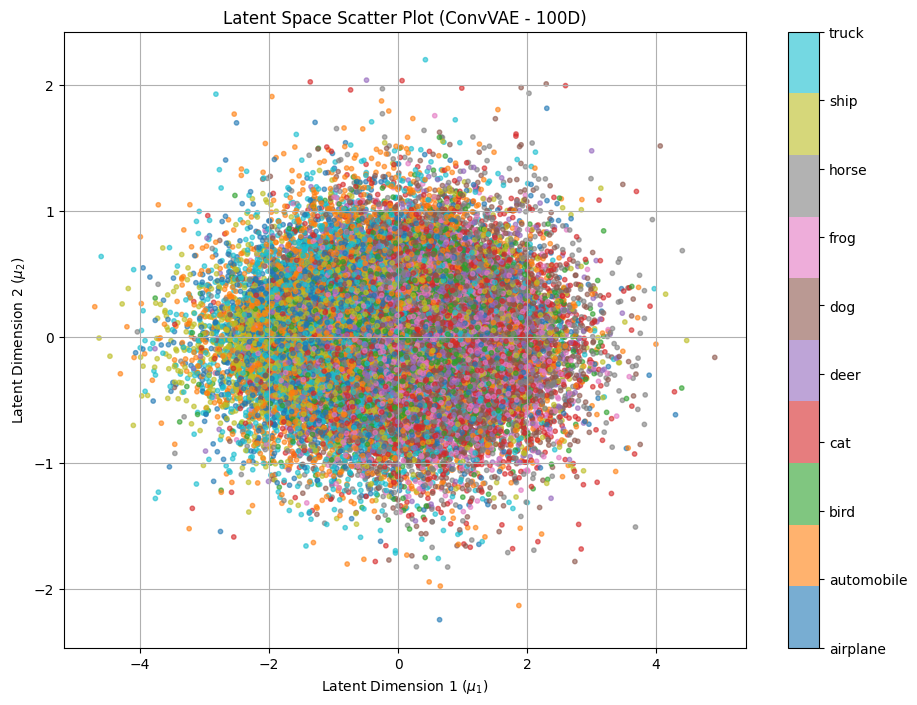

In [28]:
import matplotlib.pyplot as plt

z_train_features, train_labels = extract_features(model, train_loader, is_dense=False)


plt.figure(figsize=(11, 8))
scatter = plt.scatter(z_train_features[:, 0], z_train_features[:, 1], c=train_labels, cmap='tab10', alpha=0.6, s=10)


cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)
# -------------------------

plt.title(f"Latent Space Scatter Plot (ConvVAE - {target_latent_dim}D)")
plt.xlabel(r"Latent Dimension 1 ($\mu_1$)")
plt.ylabel(r"Latent Dimension 2 ($\mu_2$)")
plt.grid(True)
plt.show()

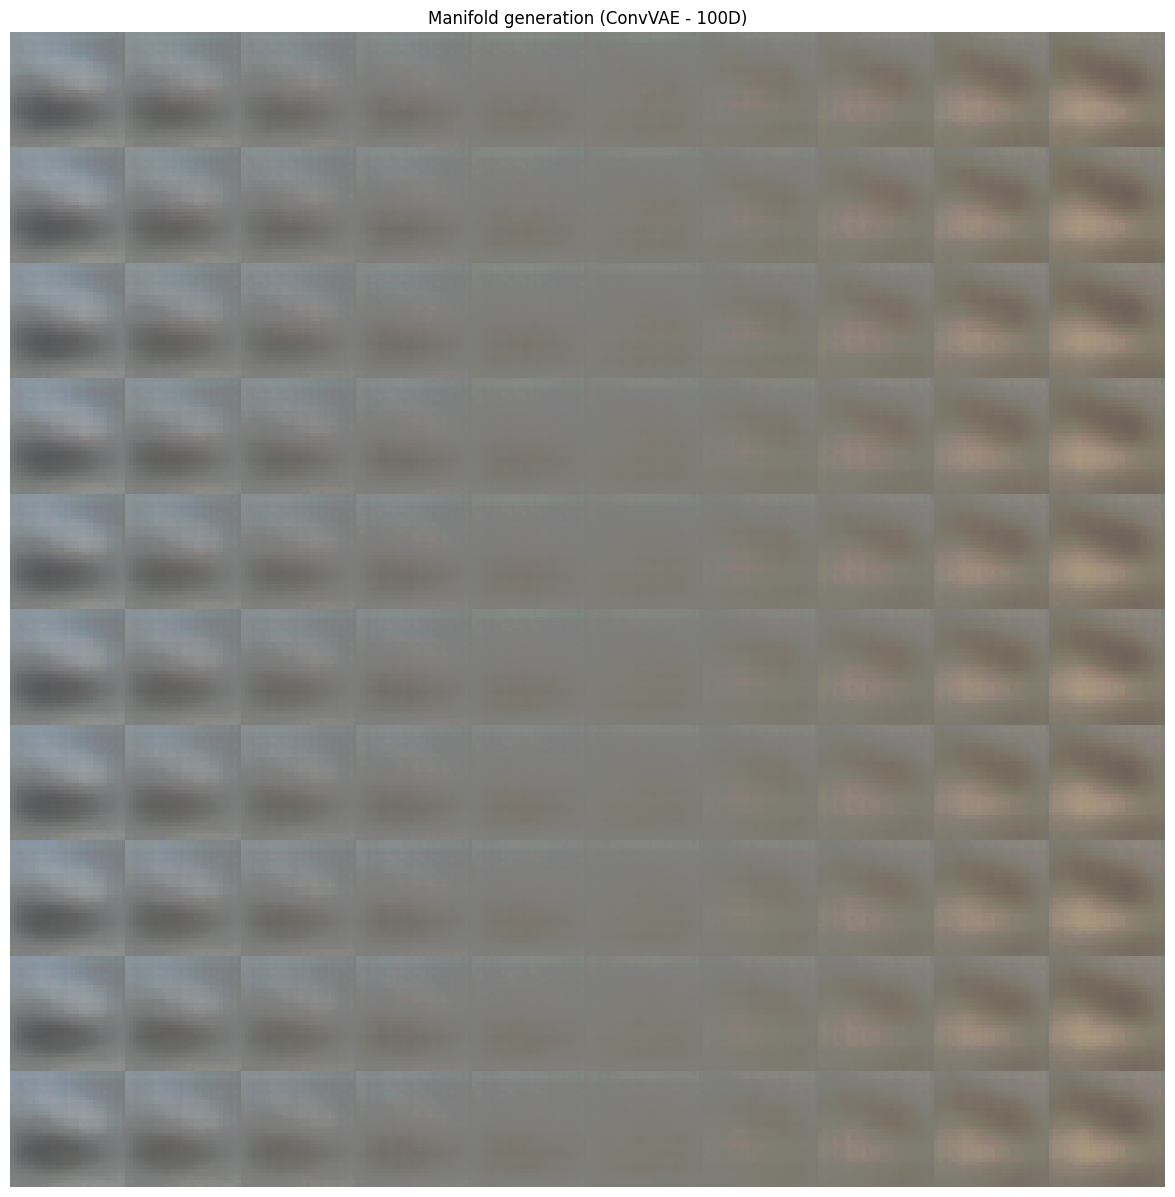

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch

n = 10
img_dim = 32
scale = 2.0
figsize = 15

# فرض می‌کنیم از مدل آموزش دیده با بعد نهفته 100 استفاده می‌کنید
target_latent_dim = 100
model = cnn_models[target_latent_dim] # انتخاب مدل از دیکشنری

figure = np.zeros((img_dim * n, img_dim * n, 3))

grid_x = np.linspace(-scale, scale, n)
grid_y = np.linspace(-scale, scale, n)[::-1]

model.eval()

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):

            z_sample = torch.zeros(1, target_latent_dim).to(device)


            z_sample[0, 0] = xi
            z_sample[0, 1] = yi


            z_projected = model.project(z_sample).view(-1, model.kernel_num, model.feature_size, model.feature_size)
            x_decoded = model.decoder(z_projected)


            img = x_decoded[0].cpu().numpy()
            img = np.transpose(img, (1, 2, 0))
            img = np.clip(img, 0, 1)

            figure[i * img_dim : (i + 1) * img_dim,
                   j * img_dim : (j + 1) * img_dim, :] = img

plt.figure(figsize=(figsize, figsize))
plt.imshow(figure)
plt.title(f"Manifold generation (ConvVAE - {target_latent_dim}D)")
plt.axis('off')
plt.show()


Shape before permute: torch.Size([60, 3, 32, 32])


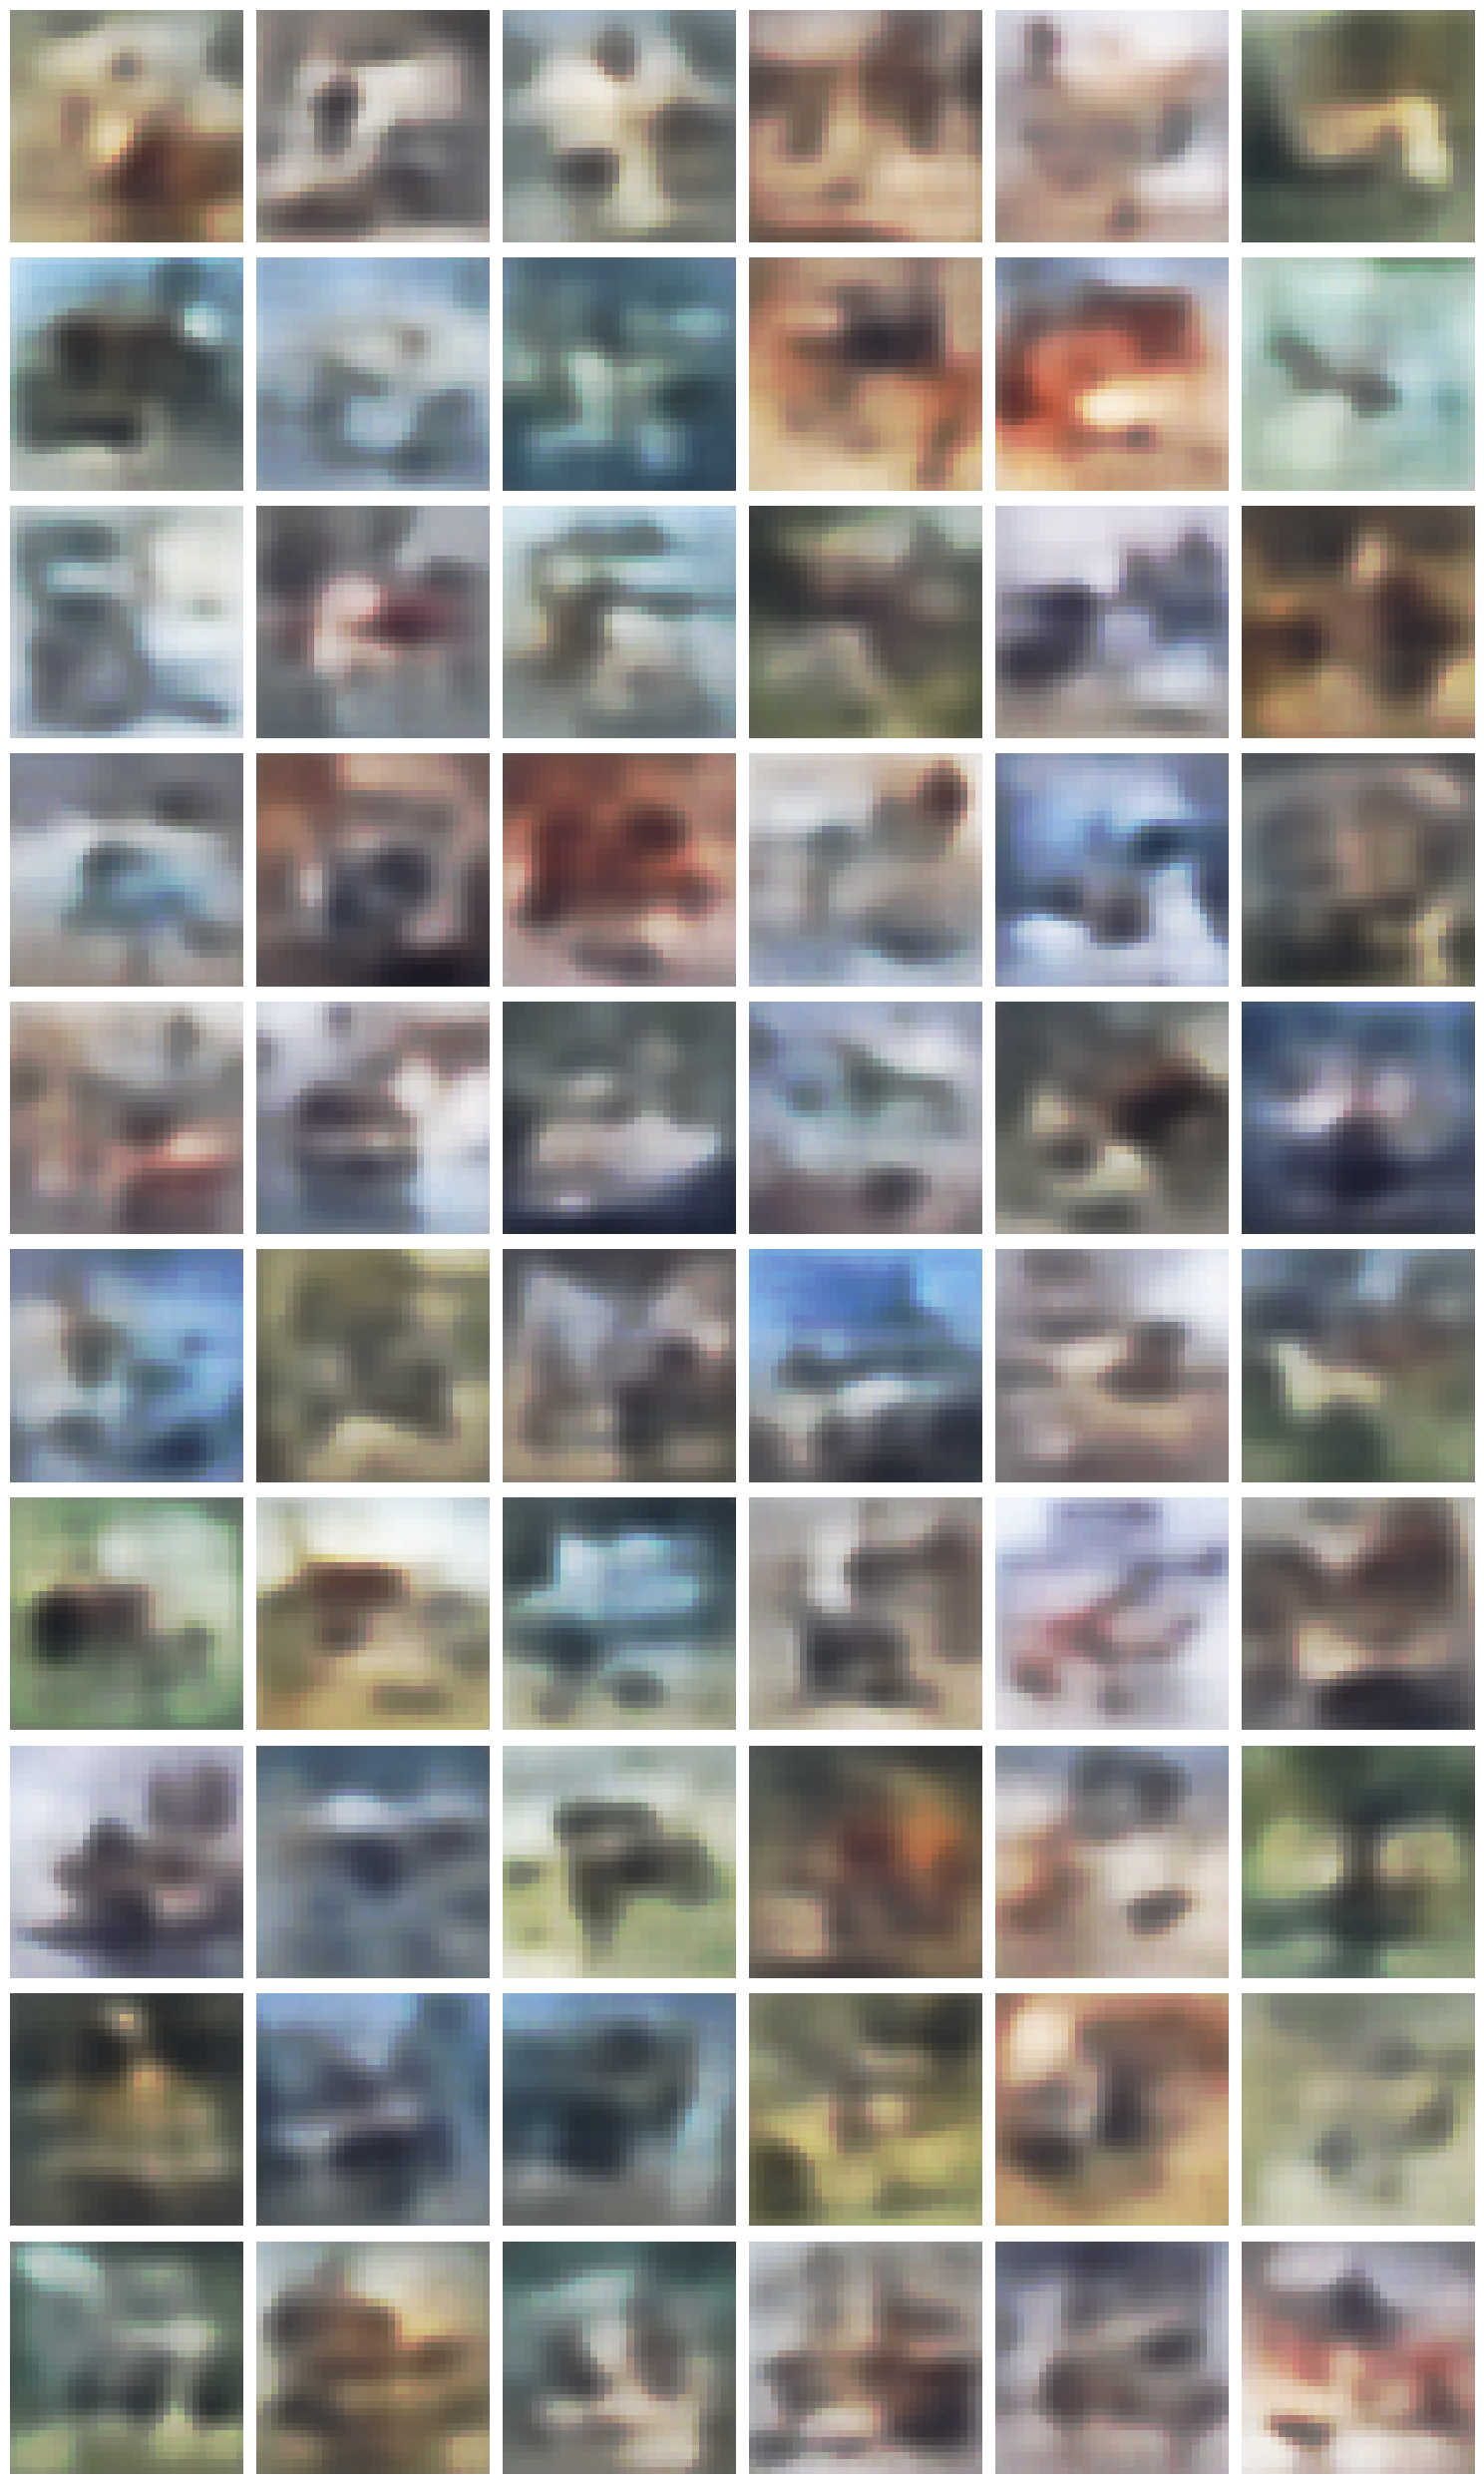

In [25]:
import matplotlib.pyplot as plt
import torch
import numpy as np

target_latent_dim = 100
model = cnn_models[target_latent_dim]
model.eval()

fig, axs = plt.subplots(10, 6, figsize=(15, 25))

with torch.no_grad():
    sixty_images_latent = torch.randn(60, target_latent_dim).to(device)


    z_projected = model.project(sixty_images_latent).view(-1, model.kernel_num, model.feature_size, model.feature_size)
    sixty_images = model.decoder(z_projected)
    # ---------------------------------------------------

    print("Shape before permute:", sixty_images.shape)


    sixty_images = sixty_images.permute(0, 2, 3, 1).cpu().numpy()


    sixty_images = np.clip(sixty_images, 0, 1)

for i in range(10):
    for j in range(6):
        idx = i * 6 + j
        axs[i][j].imshow(sixty_images[idx])
        axs[i][j].axis('off')

plt.tight_layout()
plt.show()

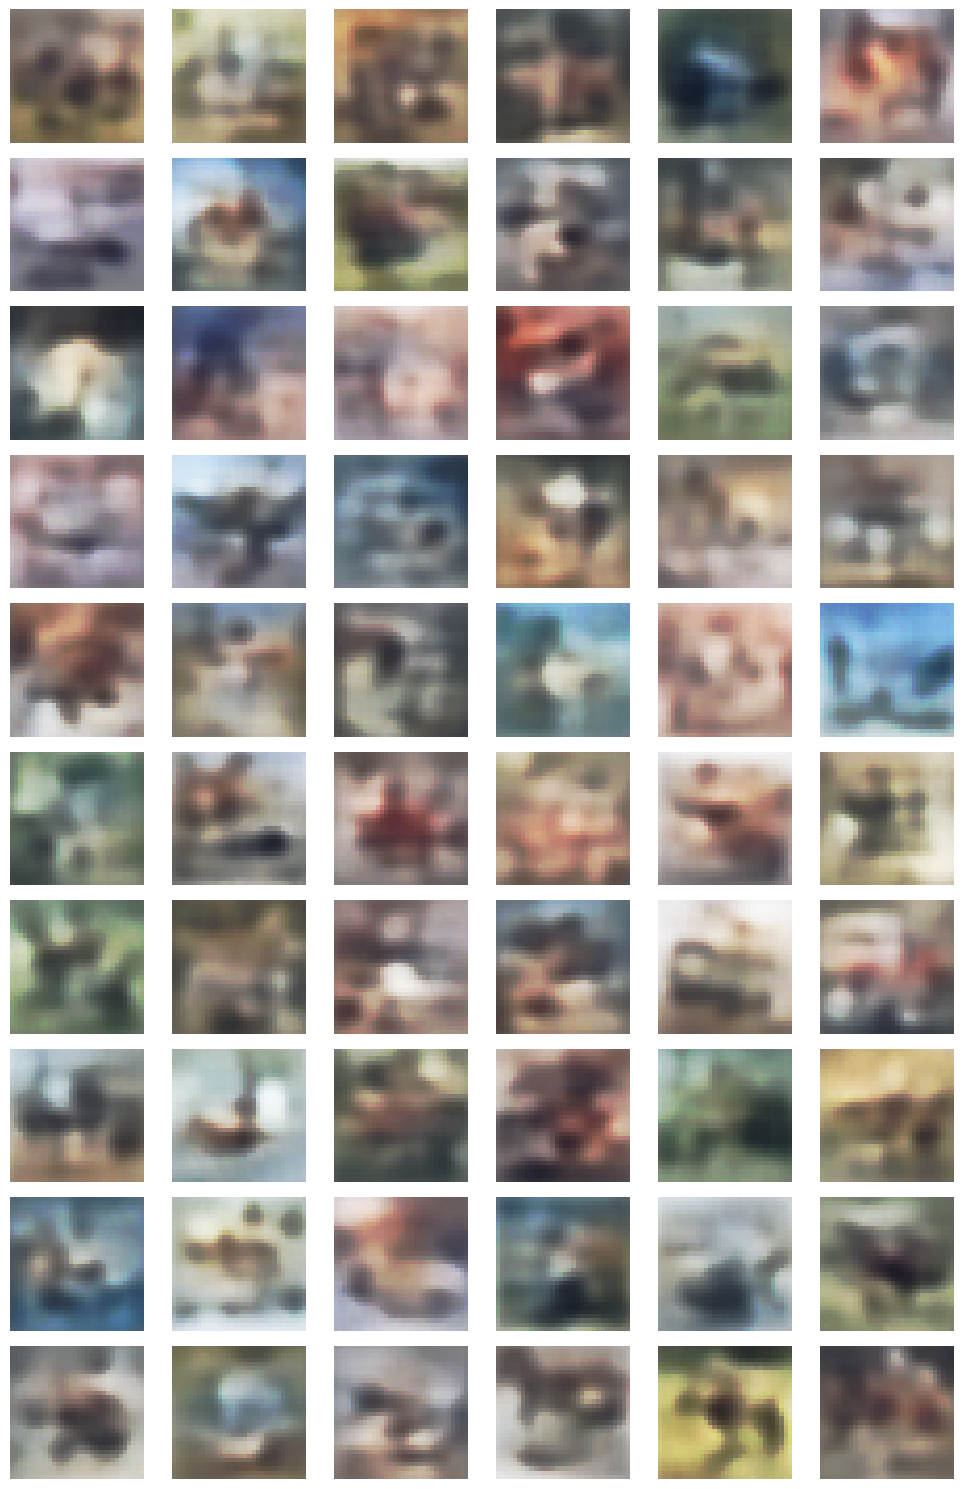

In [27]:
fig, axs = plt.subplots(10, 6, figsize=(10, 15))

with torch.no_grad():
    sixty_images_latent = torch.randn(60, target_latent_dim).to(device)
    z_projected = model.project(sixty_images_latent).view(-1, model.kernel_num, model.feature_size, model.feature_size)
    sixty_images = model.decoder(z_projected)

    sixty_images = sixty_images.permute(0, 2, 3, 1).cpu().numpy()
    sixty_images = np.clip(sixty_images, 0, 1)

for i in range(10):
    for j in range(6):
        idx = i * 6 + j

        axs[i][j].imshow(sixty_images[idx], interpolation='nearest')
        axs[i][j].axis('off')

plt.tight_layout()
plt.show()